# Volatility Modeling with GARCH

Author: Drew Glover

Date: March 31, 2026

---

### **1. The Idea: The Why and the What**

This project provides a professional, Object-Oriented implementation of a **GARCH(1,1) model** for analyzing and forecasting the volatility of a single financial asset.

*   **The "What":** Volatility is a measure of the magnitude of an asset's price changes; it is the most common measure of financial risk.
*   **The "Why":** Volatility is not constant. It exhibits **volatility clustering**, a well-documented phenomenon where high-risk periods are followed by more high-risk periods, and low-risk periods are followed by more low-risk periods. A GARCH model is the industry-standard tool for capturing this time-varying behavior.

### **2. The Use Case: The Real-World Problem Statement**

**Scenario:** We are a quantitative risk analyst at a hedge fund. A portfolio manager needs a forward-looking estimate of risk for a key stock in their portfolio, Apple Inc. (`AAPL`), to make informed decisions about derivatives pricing and position sizing.

**The Challenge:** A simple historical standard deviation is a backward-looking and static measure that fails to capture the current volatility regime. We need to build a dynamic model that adapts to the latest market information to provide a more accurate forecast.

### **3. Our Approach: A Professional OOP Framework**

We will build a `VolatilityModeler` class that encapsulates the entire GARCH analysis workflow. This OOP approach ensures our code is:
*   **Reusable:** We can easily run the same robust analysis on any other stock just by changing the input ticker.
*   **Structured:** It organizes the project into logical, understandable components (data handling, model fitting, evaluation).
*   **Professional:** It mirrors the structure of real-world quantitative finance libraries.

The workflow will follow three distinct phases:
1.  **Justification:** Download the data and use statistical tests (ADF and ARCH tests) to prove that a GARCH model is the appropriate tool.
2.  **Implementation:** Fit a GARCH(1,1) model to the data to estimate its key parameters (omega, alpha, beta).
3.  **Evaluation & Forecasting:** Analyze the model's residuals to validate its performance and then use it to generate a multi-day volatility forecast.

### **4. Key Concepts to be Implemented**

*   **Logarithmic Returns:** The foundation of all time-series modeling.
*   **Stationarity:** Confirmed with the Augmented Dickey-Fuller (ADF) test.
*   **ARCH Effects:** Confirmed with Engle's ARCH test.
*   **GARCH(1,1) Model:** The core of our analysis.
*   **Maximum Likelihood Estimation:** The method used to fit the model.
*   **Residual Analysis:** The method for validating the model's performance.

---

In [6]:
# Import the foundational libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch

class VolatilityModeler:
    """
    A class object to model and forecast the volatility of a single stock using the GARCH(1,1) model.
    """
    trading_days = 252

    def __init__(self, ticker, start_date, end_date):
        """
        Initializes the class obhect.

        Parameters:
        1. ticker (str): Stock ticker to analyze (example: AAPL)
        2. start_date (str): The start date of the historical data (yyyy-mm-dd).
        2. end_date (str): The end date of the historical data (yyyy-mm-dd).
        """

        # Store the initial parameters
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date

        # Create empty attribues to store the results.
        self.log_returns = None
        self.is_stationary = None
        self.has_arch_effects = None
        self.model_results = None


# Testing our blueprint--
test_modeler = VolatilityModeler(ticker = 'AAPL', start_date = '2018-01-01', end_date = '2023-12-31')

print(f"Name of the Stock: {test_modeler.ticker}")
print(f"\nStart and End Date of the historical data for the {test_modeler.ticker} stock: {test_modeler.start_date} to {test_modeler.end_date}")
print(f"\nCurrent Log Return of {test_modeler.ticker}: {test_modeler.log_returns}")

Name of the Stock: AAPL

Start and End Date of the historical data for the AAPL stock: 2018-01-01 to 2023-12-31

Current Log Return of AAPL: None


In [14]:
def _prepare_data(self):
    """
    Internal helper function to download the historical data of the stock and calculate the log returns.
    """
    print(f"\nPreparing the data for {self.ticker} stock...")

    # Download the CLOSE price for this ticker from yfinance
    price_data = yf.download(self.ticker, start=self.start_date, end=self.end_date, auto_adjust=True)['Close']

    if price_data.isnull().values.any():
        print("Price data has missing values. Imputing these missing values with forward fill method.")
    else:
        price_data.ffill(inplace=True)

    print(f"\nCalculating the daily logarithmic returns for {self.ticker}...")
    self.log_returns = np.log(price_data / price_data.shift(1))
    self.log_returns = self.log_returns.dropna()
    print("\nDaily Logarithmic Returns Calculated...")
    print("\nData Preparation Complete.")

VolatilityModeler._prepare_data = _prepare_data

# Testing the new method.
test_modeler._prepare_data()

print(f"\nLog Returns for {test_modeler.ticker}:\n {test_modeler.log_returns.head(10)}")

[*********************100%***********************]  1 of 1 completed


Preparing the data for AAPL stock...

Calculating the daily logarithmic returns for AAPL...

Daily Logarithmic Returns Calculated...

Data Preparation Complete.

Log Returns for AAPL:
 Ticker          AAPL
Date                
2018-01-03 -0.000174
2018-01-04  0.004635
2018-01-05  0.011321
2018-01-08 -0.003721
2018-01-09 -0.000115
2018-01-10 -0.000229
2018-01-11  0.005664
2018-01-12  0.010274
2018-01-16 -0.005095
2018-01-17  0.016381


In [23]:
# Define the STATIONARTIY TEST method.
def _test_stationarity(self):
    """
    An internal helper function to perform the Augmented Dickey-Fuller (ADF) test on the log returns to check for stationairty.
    """
    # Check whether the log returns were generated or not.
    if self.log_returns is None:
        self._prepare_data()

    print("\n --- Running the ADF Stationarity Test ---")

    # run the ADF test on Log Returns
    adf_result = adfuller(self.log_returns)

    # Extracting the p-value from te ADF Results
    p_value = adf_result[1]

    print(f"\nADF Statistic: {adf_result[0]:.4f}")
    print(f"\np-Value: {p_value:.4f}")

    # Check the p-value against our significance level of 5% or not.
    if p_value < 0.05:
        print("Result: The time series is STATIONARY (p-value is less than 0.05). We can proceed.")
        self.is_stationary = True
    else:
        print("Result: The time series is NOT STATIONARY (p-value is not less than 0.05. GARCH modelling is not appropriate.")
        self.is_stationary = False

# Define the ARCH Test method:
def _test_arch_effect(self):
    """
    An internal helper function to perform the Engle's ARCH test on the log returns to check for volatility clustering.
    """
    # Check whether the log returns were generated or not.
    if self.log_returns is None:
        self._prepare_data()

    print("\n\n--- Running the Engle's ARCH Effects Test ---")

    # Run the Engle's ARCH test
    arch_results = het_arch(self.log_returns)

    # Extract the p-value
    p_value = arch_results[1]

    print(f"\nLM Statistic: {arch_results[0]:.4f}")
    print(f"\np-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("Result: Significant ARCH Effects found as p-value is less than 0.05. GARCH Model is appropriate")
        self.has_arch_effects = True
    else:
        print("Result: No significant ARCH Effects found as p-value is not less than 0.05. GARCH Model not needed.")
        self.has_arch_effects = False

VolatilityModeler._test_stationarity = _test_stationarity
VolatilityModeler._test_arch_effect = _test_arch_effect

# Testing the new methods
test_modeler._test_stationarity()
test_modeler._test_arch_effect()

print("\n\n=====================================")
print(f"Time Series is Stationary: {test_modeler.is_stationary}")
print(f"\nTime Series as ARCH Effects: {test_modeler.has_arch_effects}")
print("=====================================")


 --- Running the ADF Stationarity Test ---

ADF Statistic: -12.1504

p-Value: 0.0000
Result: The time series is STATIONARY (p-value is less than 0.05). We can proceed.


--- Running the Engle's ARCH Effects Test ---

LM Statistic: 264.5802

p-Value: 0.0000
Result: Significant ARCH Effects found as p-value is less than 0.05. GARCH Model is appropriate


Time Series is Stationary: True

Time Series as ARCH Effects: True


In [24]:
# Define the method's logic:
def fit_garch_model(self):
    """
    This is the main public method to run the full GARCH(1,1) analysis. It performs the pre-requisite checks and then fits the model.
    """
    print("\n--- Starting the GARCH(1,1) Model Fitting Process ---")

    if self.log_returns is None:
        self._prepare_data()

    # Run the statistical checks.
    self._test_stationarity()
    self._test_arch_effect()

    # Check the test results before proceeding.
    if self.is_stationary is False or self.has_arch_effects is False:
        print("\nPrerequisite checks failed. Cannot proceed with GARCH(1,1) model fitting. Aborting process...")
        return

    print("\nPrerequisite checks passed. Fitting the GARCH(1,1) Model...")

    # Scale the log returns by 100 for better numerical visibility.
    scaled_returns = self.log_returns * 100

    # Define the GARCH model parameters.
    # p=1 and q=1 specifies the ARCH and GARCH lags respectively.
    # dist='Normal' assumes a normal distribution for the errors.
    model = arch_model(scaled_returns, p=1, q=1, vol='Garch', dist='Normal')

    # Fit the model to the data.
    self.model_results = model.fit()

    print("\nModel Fitting Complete.")
    print("\nGARCH Model Summary:")
    print(self.model_results.summary())

VolatilityModeler.fit_garch_model = fit_garch_model

# Testing thenew method
final_test = VolatilityModeler(ticker = 'NVDA',
                               start_date = '2018-01-01',
                               end_date = '2024-12-31')
final_test.fit_garch_model()


--- Starting the GARCH(1,1) Model Fitting Process ---

Preparing the data for NVDA stock...


[*********************100%***********************]  1 of 1 completed



Calculating the daily logarithmic returns for NVDA...

Daily Logarithmic Returns Calculated...

Data Preparation Complete.

 --- Running the ADF Stationarity Test ---

ADF Statistic: -13.3116

p-Value: 0.0000
Result: The time series is STATIONARY (p-value is less than 0.05). We can proceed.


--- Running the Engle's ARCH Effects Test ---

LM Statistic: 98.0655

p-Value: 0.0000
Result: Significant ARCH Effects found as p-value is less than 0.05. GARCH Model is appropriate

Prerequisite checks passed. Fitting the GARCH(1,1) Model...
Iteration:      1,   Func. Count:      6,   Neg. LLF: 11412.767249327866
Iteration:      2,   Func. Count:     16,   Neg. LLF: 24908.74090954108
Iteration:      3,   Func. Count:     23,   Neg. LLF: 6905.177759717521
Iteration:      4,   Func. Count:     30,   Neg. LLF: 5088.189872440182
Iteration:      5,   Func. Count:     37,   Neg. LLF: 4455.928385252411
Iteration:      6,   Func. Count:     42,   Neg. LLF: 4455.986232091336
Iteration:      7,   Func. Co

--- Testing the new evaluation and forecasting methods ---

--- Running Model Evaluations: Residual Analysis ---


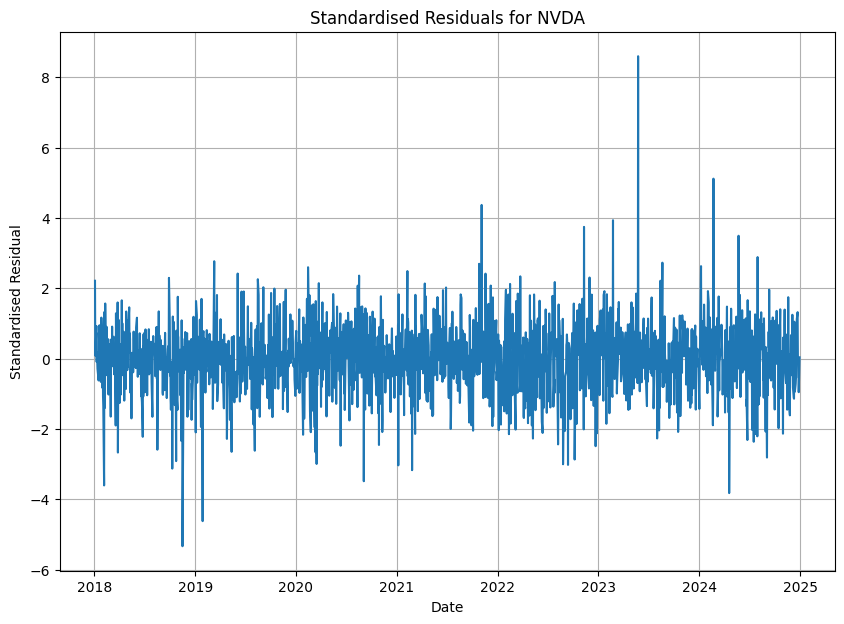


Running ARCH Test on Standard Residuals...

LM Statistic: 0.0889

p-Value: 1.0000

 Result: Success! No Significant ARCH Effects remains in the residuals (p_value > 0.05).

Generating Volatility Forecasting for NVDA for 10 days...
      Daily Volatility  Annualized Volatility
h.01          0.024179               0.383832
h.02          0.024684               0.391848
h.03          0.025158               0.399365
h.04          0.025603               0.406427
h.05          0.026021               0.413070
h.06          0.026415               0.419326
h.07          0.026787               0.425224
h.08          0.027137               0.430791
h.09          0.027469               0.436051
h.10          0.027782               0.441023


,Daily Volatility,Annualized Volatility
h.01,0.024179,0.383832
h.02,0.024684,0.391848
h.03,0.025158,0.399365
h.04,0.025603,0.406427
h.05,0.026021,0.413070
h.06,0.026415,0.419326
h.07,0.026787,0.425224
h.08,0.027137,0.430791
h.09,0.027469,0.436051
h.10,0.027782,0.441023


In [29]:
def plot_residuals(self):
    """
    Plot the standardised residulas of the fitted model to help evaluate the model's performance. Also runs an ARCH test on the residuals.
    """
    # Check if the model is fitted.
    if self.model_results is None:
        print("\nThe model has not been fitted yet. Please run the fit_garch_model() first.")
        return

    print("\n--- Running Model Evaluations: Residual Analysis ---")

    # Plot the residuals
    plt.figure(figsize=(10,7))
    plt.plot(self.model_results.std_resid)
    plt.title(f"Standardised Residuals for {self.ticker}")
    plt.xlabel('Date')
    plt.ylabel('Standardised Residual')
    plt.grid(True)
    plt.show()

    # Statistical check on residuals
    print("\nRunning ARCH Test on Standard Residuals...")
    arch_test_result = het_arch(self.model_results.std_resid**2)
    p_value = arch_test_result[1]

    print(f"\nLM Statistic: {arch_test_result[0]:.4f}")
    print(f"\np-Value: {p_value:.4f}")

    if p_value < 0.05:
        print("\n Result: Warning! Significant ARCH Effects still remains in the residuals (p_value < 0.05).")
    else:
        print("\n Result: Success! No Significant ARCH Effects remains in the residuals (p_value > 0.05).")

def forecast_volatility(self, horizon=10):
    """
    Forecasts conditional volatility for a specified number of future periods.
    Parameters:
    1. horizon=5 (int): The number of days to forecast in the future.
    """
    # Check if the model is fitted.
    if self.model_results is None:
        print("\nThe model has not been fitted yet. Please run the fit_garch_model() first.")
        return

    print(f"\nGenerating Volatility Forecasting for {self.ticker} for {horizon} days...")

    forecast = self.model_results.forecast(horizon=horizon)

    # Extract the last row for variance forecast
    future_variances = forecast.variance.iloc[-1]

    # Getting the standard deviation and scaling back
    future_daily_volatility = np.sqrt(future_variances) / 100

    # Annualized the daily volatility
    future_annualised_volatility = future_daily_volatility * np.sqrt(self.trading_days)

    # Present the result in the dataframe
    forecast_df = pd.DataFrame({'Daily Volatility': future_daily_volatility, 'Annualized Volatility': future_annualised_volatility})

    print(forecast_df)
    return forecast_df

VolatilityModeler.plot_residuals = plot_residuals
VolatilityModeler.forecast_volatility = forecast_volatility

# Final Tests
print("--- Testing the new evaluation and forecasting methods ---")
final_test.plot_residuals()
final_test.forecast_volatility()